In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd


df = pd.read_excel('/content/Expectation_Decider_Dataset.xlsx')

In [10]:
df.shape

(500, 5)

In [11]:
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,9.5,84.6,Yes,49.5,Fail
1,9.1,74.6,Yes,39.1,Fail
2,9.5,82.7,No,57.2,Fail
3,2.5,81.9,Yes,35.8,Fail
4,9.5,75.7,No,48.0,Fail


In [12]:
df.tail()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
495,5.6,92.0,Yes,50.2,Fail
496,14.7,94.2,No,73.4,Pass
497,13.7,77.7,No,40.9,Fail
498,6.2,68.5,Yes,47.4,Fail
499,19.8,48.7,Yes,58.4,Fail


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   study_hours          500 non-null    float64
 1   attendance           500 non-null    float64
 2   group_discussion     500 non-null    object 
 3   previous_test_score  500 non-null    float64
 4   final_exam_pass      500 non-null    object 
dtypes: float64(3), object(2)
memory usage: 19.7+ KB


In [17]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['study_hours', 'attendance', 'group_discussion', 'previous_test_score',
       'final_exam_pass'],
      dtype='object')


In [19]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
study_hours            0
attendance             0
group_discussion       0
previous_test_score    0
final_exam_pass        0
dtype: int64


In [20]:
df.describe()

,study_hours,attendance,previous_test_score
count,500.000000,500.00000,500.000000
mean,10.926600,72.85800,53.972600
std,5.137078,15.85091,15.920519
min,2.000000,45.00000,20.000000
25%,6.500000,59.05000,41.750000
50%,10.800000,73.65000,53.400000
75%,15.025000,86.20000,65.550000
max,19.900000,99.80000,94.100000


The calculated probability represents the likelihood
that a randomly selected student passes the final exam.

A higher probability indicates better overall academic performance.

$$
P(\text{Pass})=\frac{\text{Number of Pass Students}}{\text{Total Students}}
$$

In [22]:
# Total students
total_students = len(df)

# Pass students
pass_students = len(df[df['final_exam_pass'] == 'Pass'])

# Probability
pass_probability = pass_students / total_students

print("Total Students:", total_students)
print("Pass Students:", pass_students)
print("Probability of Passing:", round(pass_probability, 2))

Total Students: 500
Pass Students: 142
Probability of Passing: 0.28


This probability measures how many students study
more than 10 hours per week.

It helps analyze student study behavior and learning patterns.

$$
P(\text{Study} > 10)=\frac{\text{Students Studying More Than 10 Hours}}{\text{Total Students}}
$$

In [24]:
study_more_10 = len(df[df['study_hours'] > 10])

probability_study_10 = study_more_10 / total_students

print("Students studying >10 hours:", study_more_10)
print("Probability:", round(probability_study_10, 2))

Students studying >10 hours: 271
Probability: 0.54


The probability shows the proportion of students
with high attendance.

Higher attendance generally indicates stronger
academic engagement and discipline.

$$
P(\text{Attendance} > 80)=\frac{\text{Students With Attendance Greater Than 80\%}}{\text{Total Students}}
$$

In [25]:
attendance_80 = len(df[df['attendance'] > 80])

probability_attendance_80 = attendance_80 / total_students

print("Students with attendance >80%:", attendance_80)
print("Probability:", round(probability_attendance_80, 2))

Students with attendance >80%: 182
Probability: 0.36


Empirical probability is based on actual observed data
from the dataset.

It provides a realistic estimate of student success rates.

In [26]:
empirical_probability = pass_students / total_students

print("Empirical Probability of Passing:")
print(round(empirical_probability, 2))

Empirical Probability of Passing:
0.28


Theoretical probability assumes equal chances of passing
and failing without considering real dataset values.

It is used for comparison with empirical probability.

$$
P(E)=\frac{\text{Favorable Outcomes}}{\text{Total Possible Outcomes}}
$$

In [27]:
theoretical_probability = 0.5

print("Theoretical Probability:")
print(theoretical_probability)

Theoretical Probability:
0.5


The binomial distribution calculates the probability
of different numbers of students passing among
3 selected students.

It helps model repeated probability experiments.

In [65]:
# n = 3 students
n = 3
p = pass_probability

print("Binomial Distribution Probabilities:\n")

for x in range(0, 4):
    probability = binom.pmf(x, n, p)
    print(f"P(X={x}) = {round(probability,4)}")

Binomial Distribution Probabilities:

P(X=0) = 0.3671
P(X=1) = 0.4368
P(X=2) = 0.1732
P(X=3) = 0.0229


The mean represents the expected number of students passing,
while the variance measures the spread or variability
in passing outcomes.

$$
\mu=np
$$

In [29]:
mean = n * p
variance = n * p * (1 - p)

print("Mean:", round(mean, 3))
print("Variance:", round(variance, 3))

Mean: 0.852
Variance: 0.61


The Venn diagram shows the relationship between
students studying more than 10 hours and students
having attendance above 80%.

The overlapping region represents students satisfying both conditions.

$$
A \cap B
$$

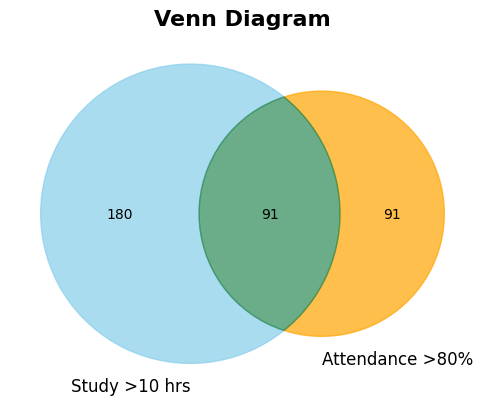

In [ ]:
import matplotlib.pyplot as plt

A = set(df[df['study_hours'] > 10].index)
B = set(df[df['attendance'] > 80].index)

plt.figure(figsize=(6,6))

v = venn2(
    [A, B],
    set_labels=('Study >10 hrs',
                'Attendance >80%')
)
v.get_patch_by_id('10').set_color('skyblue')
v.get_patch_by_id('01').set_color('orange')
v.get_patch_by_id('11').set_color('seagreen')
v.get_patch_by_id('10').set_alpha(0.7)
v.get_patch_by_id('01').set_alpha(0.7)
v.get_patch_by_id('11').set_alpha(0.7)

plt.title("Venn Diagram",
          fontsize=16,
          fontweight='bold')

plt.show()

The contingency table compares group discussion participation
with final exam results.

It helps identify whether discussion participation
affects passing probability.


In [32]:
contingency_table = pd.crosstab(
    df['group_discussion'],
    df['final_exam_pass']
)

print(contingency_table)

final_exam_pass   Fail  Pass
group_discussion            
No                 197    52
Yes                161    90


Joint probability measures the likelihood that
two events occur together.

Here, it represents students who both participated
in group discussions and passed the exam.

$$
P(A \cap B)=\frac{\text{Both Events Occur}}{\text{Total Students}}
$$

In [33]:
joint_count = len(df[
    (df['group_discussion'] == 'Yes') &
    (df['final_exam_pass'] == 'Pass')
])

joint_probability = joint_count / total_students

print("Joint Probability:")
print(round(joint_probability, 3))

Joint Probability:
0.18


Marginal probability calculates the probability
of a single event occurring independently.

In this project, it represents the overall
probability of passing the exam.

$$
P(A)=\frac{\text{Event A Outcomes}}{\text{Total Outcomes}}
$$

In [34]:
marginal_probability = pass_students / total_students

print("Marginal Probability of Passing:")
print(round(marginal_probability, 3))

Marginal Probability of Passing:
0.284


Conditional probability measures the probability
of passing the exam given that a student
participated in group discussions.

It helps understand dependent relationships between events.

$$
P(A|B)=\frac{P(A \cap B)}{P(B)}
$$

In [35]:
discussion_students = len(df[df['group_discussion'] == 'Yes'])

conditional_probability = joint_count / discussion_students

print("Conditional Probability:")
print(round(conditional_probability, 3))

Conditional Probability:
0.359


The bar chart visually compares the number
of students who passed and failed.

It provides a quick understanding of overall exam performance.

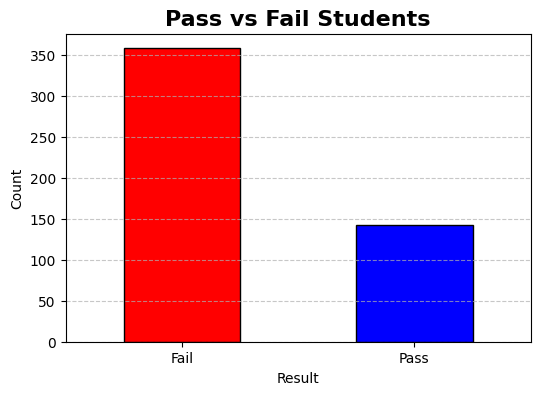

In [57]:
import matplotlib.pyplot as plt

pass_fail_counts = df['final_exam_pass'].value_counts()

plt.figure(figsize=(6,4))

pass_fail_counts.plot(
    kind='bar',
    color=['red', 'blue'],
    edgecolor='black'
)

plt.title("Pass vs Fail Students",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Result")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

The histogram displays the distribution
of student attendance percentages.

It helps identify attendance patterns
and concentration of students in different attendance ranges.

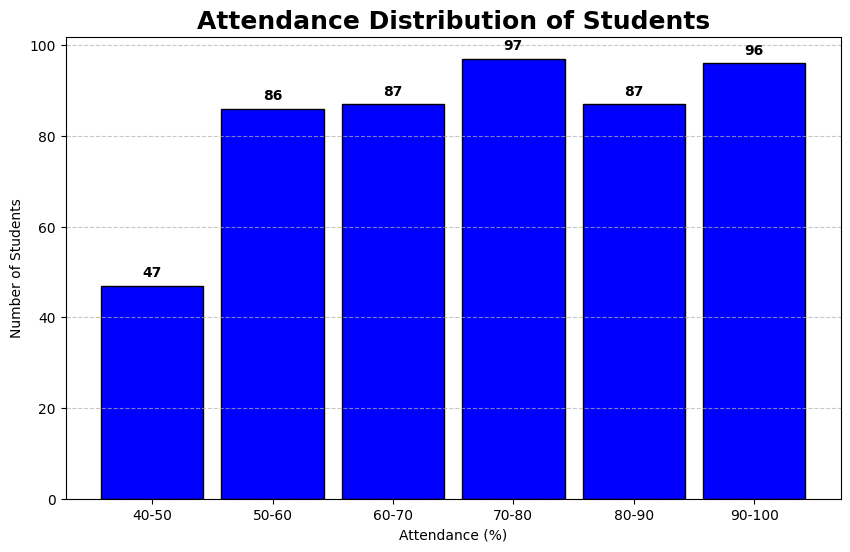

In [58]:
import matplotlib.pyplot as plt

bins = [40, 50, 60, 70, 80, 90, 100]

plt.figure(figsize=(10,6))

counts, _, bars = plt.hist(
    df['attendance'],
    bins=bins,
    color='blue',
    edgecolor='black',
    rwidth=0.85
)
for count, bar in zip(counts, bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        count + 2,
        int(count),
        ha='center',
        fontweight='bold'
    )

plt.title("Attendance Distribution of Students",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")

plt.xticks(
    [45,55,65,75,85,95],
    ['40-50','50-60','60-70',
     '70-80','80-90','90-100']
)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

The scatter plot shows the relationship between
study hours and previous test scores.

An upward trend indicates that students
who study more tend to achieve better scores

$$
y=mx+c
$$

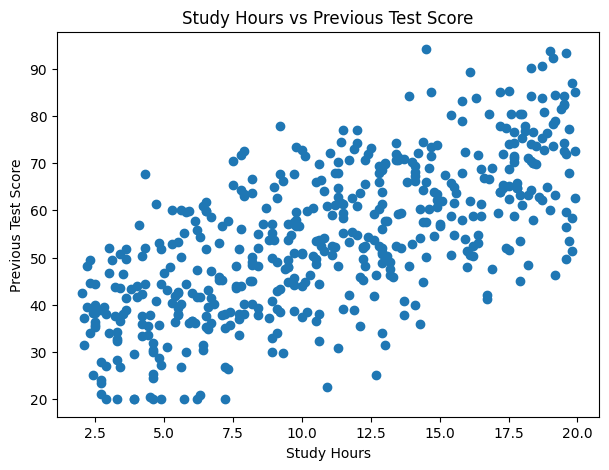

In [38]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['study_hours'],
    df['previous_test_score']
)

plt.title("Study Hours vs Previous Test Score")
plt.xlabel("Study Hours")
plt.ylabel("Previous Test Score")

plt.show()

Bayes' theorem calculates the probability
that a student passed given high attendance.

The result shows how attendance influences academic success.

In [66]:
P_B_given_A = 0.70
P_A = pass_probability
P_B = 0.60
bayes_result = (P_B_given_A * P_A) / P_B

print("Bayes Theorem Result:")
print(round(bayes_result, 3))

Bayes Theorem Result:
0.331


Correlation analysis measures the strength
and direction of relationships between variables.

Positive correlation indicates that one variable
increases as another variable increases.

In [40]:
correlation = df[
    ['study_hours',
     'attendance',
     'previous_test_score']
].corr()

print(correlation)

                     study_hours  attendance  previous_test_score
study_hours             1.000000   -0.027031             0.690895
attendance             -0.027031    1.000000             0.408837
previous_test_score     0.690895    0.408837             1.000000


The heatmap visually represents correlations
between study hours, attendance,
and previous test scores.

Darker values indicate stronger relationships.

$$
r=\frac{\sum (x-\bar{x})(y-\bar{y})}
{\sqrt{\sum (x-\bar{x})^2 \sum (y-\bar{y})^2}}
$$

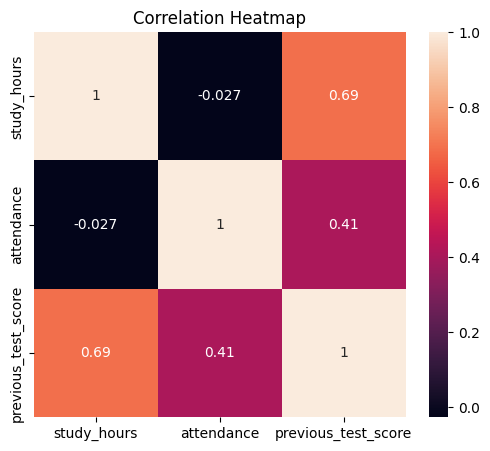

In [41]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(correlation,
            annot=True)

plt.title("Correlation Heatmap")

plt.show()

Bayes' theorem was used to calculate the probabilitythat a student passed the exam given thatthe student had high attendance.The result indicates that students with higher attendancehave a greater chance of passing the final exam.This shows that attendance positively influencesacademic performance and exam success.

In [67]:
total_students = len(df)
passed_students = df[df['final_exam_pass'] == 'Pass']
high_attendance_students = df[df['attendance'] > 80]
passed_high_attendance = df[
    (df['final_exam_pass'] == 'Pass') &
    (df['attendance'] > 80)
]
P_A = len(passed_students) / total_students

P_B = len(high_attendance_students) / total_students

P_B_given_A = len(passed_high_attendance) / len(passed_students)
P_A_given_B = (P_B_given_A * P_A) / P_B

print("P(A) =", round(P_A,3))
print("P(B) =", round(P_B,3))
print("P(B|A) =", round(P_B_given_A,3))

print("\nProbability that a student passed given high attendance:")
print("P(A|B) =", round(P_A_given_B,3))

P(A) = 0.284
P(B) = 0.364
P(B|A) = 0.704

Probability that a student passed given high attendance:
P(A|B) = 0.549


The bar graph represents the probabilities used in Bayes' theorem analysis.The first bar shows the overall probability of students passing the exam.The second bar represents the probability of students having high attendance.The third bar shows the conditional probability of passing given high attendance.The graph indicates that students with high attendancehave a higher likelihood of passing the final exam.This demonstrates a positive relationship between attendanceand academic performance.

$$
P(A|B)=\frac{P(B|A)P(A)}{P(B)}
$$

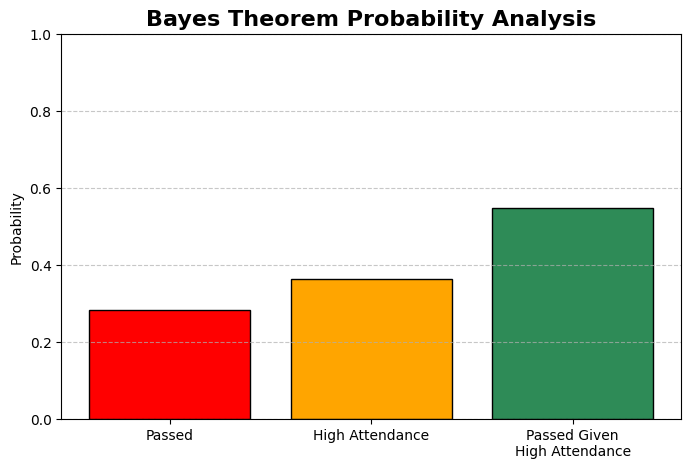

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ['Passed',
     'High Attendance',
     'Passed Given\nHigh Attendance'],

    [P_A, P_B, P_A_given_B],

    color=['red', 'orange', 'seagreen'],
    edgecolor='black'
)
plt.title("Bayes Theorem Probability Analysis",
          fontsize=16,
          fontweight='bold')
plt.ylabel("Probability")

plt.ylim(0,1)
plt.grid(axis='y',
         linestyle='--',
         alpha=0.7)

plt.show()

Conclusion:The Expectation Decider Analysis sccessfully applied
probability and statistical analysis techniques
to evaluate student academic performance.

The analysis showed that students with higher
study hours, better attendance, and participation
in group discussions had a greater probability
of passing the final exam.

Different probability concepts such as empirical probability,
conditional probability, joint probability,
binomial distribution, and Bayes’ theorem
were used to identify important academic patterns
within the dataset.

The graphical analysis, including histograms,
bar charts, scatter plots, heatmaps,
and Venn diagrams, helped visualize relationships
between student behaviors and exam outcomes.

The project demonstrates how probability
and data analysis can be used in real-world
educational decision-making and performance prediction.